In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
dataset = fetch_openml(data_id=41554, as_frame=True)

df = dataset.frame

print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  


In [3]:
df.describe()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,2.963384,2.631769,0.142061,0.228412,0.607242,0.022284,0.211699,0.345404,0.247911,0.016713,0.178273,35.017827,20.018217,54.630975,75.881894,1.288237,9.439086,23.585471
std,0.980822,1.269089,0.349600,0.420396,0.489045,0.147812,0.409083,0.476163,0.432402,0.128373,0.383277,10.662561,8.094140,33.097935,30.818669,0.859098,3.568250,22.267948
min,0.491000,0.524000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.320000,1.980000,18.680000,25.000000,0.135000,1.552000,3.552000
25%,2.260500,1.510500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.640000,14.600000,36.320000,54.600000,0.652500,6.660000,10.470000
50%,3.040000,2.489000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.800000,20.680000,46.800000,73.560000,1.100000,9.840000,17.200000
75%,3.674000,3.652000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,41.460000,25.380000,60.200000,90.000000,1.680000,12.100000,26.920000
max,4.920000,5.690000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,53.200000,300.000000,259.840000,5.129000,20.600000,166.400000


In [4]:
df.columns

Index(['Xloc', 'Yloc', 'Landuse_1', 'Landuse_2', 'Landuse_3', 'Landuse_4',
       'Rock_1', 'Rock_2', 'Rock_3', 'Rock_4', 'Rock_5', 'Cr', 'Ni', 'Pb',
       'Zn', 'Cd', 'Co', 'Cu'],
      dtype='object')

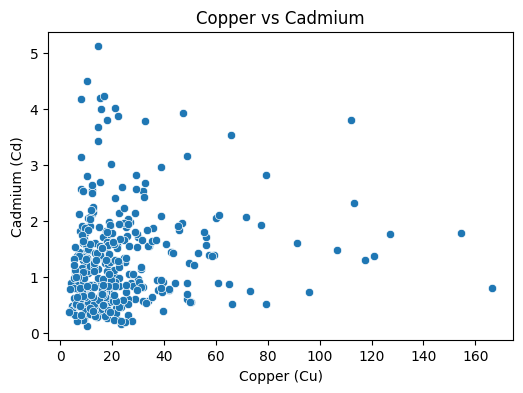

In [6]:
if 'Cd' in df.columns and 'Cu' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df['Cu'], y=df['Cd'])
    plt.title("Copper vs Cadmium")
    plt.xlabel("Copper (Cu)")
    plt.ylabel("Cadmium (Cd)")
    plt.show()


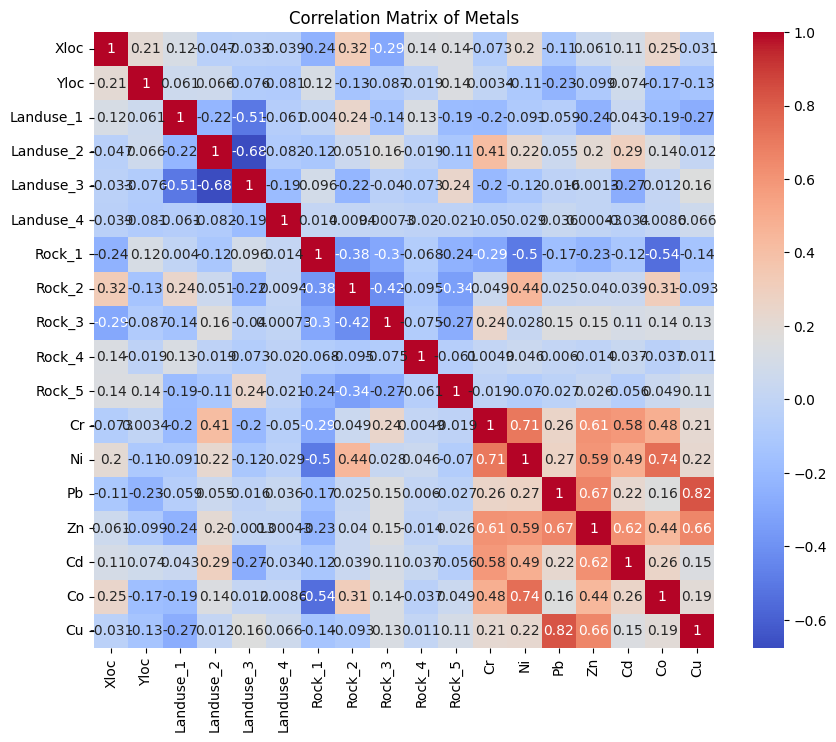

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Metals")
plt.show()

In [9]:
Y = df['Cd']

X = df.drop(columns=['Cd'])

X = X.fillna(X.mean())

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

print("\nShape after Polynomial Features:", X_poly.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


Shape after Polynomial Features: (359, 170)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [13]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

Lasso(max_iter=10000)

In [14]:
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

r2_linear = r2_score(y_test, y_pred_linear)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Linear Regression -> RMSE: {rmse_linear:.4f}, R2: {r2_linear:.4f}")
print(f"Ridge Regression  -> RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")
print(f"Lasso Regression  -> RMSE: {rmse_lasso:.4f}, R2: {r2_lasso:.4f}")


========== MODEL PERFORMANCE ==========
Linear Regression -> RMSE: 0.8328, R2: -0.0690
Ridge Regression  -> RMSE: 0.5437, R2: 0.5445
Lasso Regression  -> RMSE: 0.8087, R2: -0.0079


In [15]:
feature_names = poly.get_feature_names_out(X.columns)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

print("\nCoefficient Comparison (Top 10):")
print(coef_df.head(10))


Coefficient Comparison (Top 10):
     Feature    Linear     Ridge  Lasso
0       Xloc -0.152636 -0.103323    0.0
1       Yloc  0.435489  0.273962    0.0
2  Landuse_1  0.041790  0.035740    0.0
3  Landuse_2 -0.066659 -0.005692    0.0
4  Landuse_3  0.010552 -0.026580   -0.0
5  Landuse_4  0.055833  0.019600   -0.0
6     Rock_1  0.085618  0.083192   -0.0
7     Rock_2  0.056927 -0.035663    0.0
8     Rock_3 -0.065768 -0.035382    0.0
9     Rock_4 -0.008226 -0.017556    0.0


In [16]:
lasso_zero_features = coef_df[coef_df["Lasso"] == 0]

print("\nNumber of features reduced to zero by Lasso:",
      lasso_zero_features.shape[0])

print("\nFeatures removed by Lasso (first 10):")
print(lasso_zero_features["Feature"].head(10))


Number of features reduced to zero by Lasso: 170

Features removed by Lasso (first 10):
0         Xloc
1         Yloc
2    Landuse_1
3    Landuse_2
4    Landuse_3
5    Landuse_4
6       Rock_1
7       Rock_2
8       Rock_3
9       Rock_4
Name: Feature, dtype: object
